In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage
from scipy.interpolate import interp1d

import glob
import time
import tifffile
from scipy.optimize import curve_fit
import sys
sys.path.append('../')
import utils

from scipy.interpolate import interp1d
from scipy.signal import savgol_filter


In [2]:
def remove_scanner_background_rotation_only(image, threshold_value=240, visualize=False):
    """
    Remove scanner background from an image with pure rotation (no distortion).
    
    Args:
        image_path: Path to the input image
        target_width: Target width for downscaling (only used if downscale=True)
        output_path: Path to save the output image (optional)
        threshold_value: Threshold for binarization (optional, auto-determined if None)
        visualize: Whether to display visualization of the detection
        downscale: Whether to downscale the image for faster processing
        
    Returns:
        The processed image with scanner background removed
    """
    
    # Create a copy for visualization
    orig_image = image.copy()
        
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
    # Apply thresholding
    _, thresh = cv2.threshold(blurred, threshold_value, 255, cv2.THRESH_BINARY_INV)
    
    # Find external contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found in the image.")
        
    # Find largest contour by area
    c = max(contours, key=cv2.contourArea)
    
    # Check if contour is large enough
    if cv2.contourArea(c) < (image.shape[0] * image.shape[1] * 0.1):
        raise ValueError("Document detection failed: largest contour too small")
    
    # Get minimum area rectangle
    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    # Get rotation angle and size from the minimum area rectangle
    angle = rect[2]
    
    # # Adjust angle for proper rotation (OpenCV's minAreaRect returns angles in [-90, 0])
    # if angle < -45:
    #     angle = 90 + angle
    
    # Get the original size of the document from the rect
    width, height = rect[1]
    
    # Make sure width is the larger dimension
    if width < height:
        width, height = height, width
        angle -= 90
    
    # Calculate the rotation matrix
    center = (image.shape[1] // 2, image.shape[0] // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Determine the new image dimensions after rotation
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    new_width = int((image.shape[0] * sin) + (image.shape[1] * cos))
    new_height = int((image.shape[0] * cos) + (image.shape[1] * sin))
    
    # Adjust the rotation matrix to take into account the translation
    M[0, 2] += (new_width / 2) - center[0]
    M[1, 2] += (new_height / 2) - center[1]
    
    # Perform the rotation
    rotated = cv2.warpAffine(image, M, (new_width, new_height), flags=cv2.INTER_CUBIC, 
                            borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
    
    # Now crop the document from the rotated image
    # Convert the box to the rotated coordinate system
    pts = np.array(box, dtype="float32")
    for i in range(4):
        # Apply rotation matrix to each point
        x = M[0, 0] * pts[i, 0] + M[0, 1] * pts[i, 1] + M[0, 2]
        y = M[1, 0] * pts[i, 0] + M[1, 1] * pts[i, 1] + M[1, 2]
        pts[i] = [x, y]
    
    # Get bounding rectangle of the rotated points
    x, y, w, h = cv2.boundingRect(np.int0(pts))
    
    # Crop the rotated image
    cropped = rotated[y:y+h, x:x+w]
    # cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    
    # # convert cropped to an RGB image
    # cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    
    return cropped

In [3]:
def logarithm(x, A, B, C):
    y = - C *(np.log(x)) + B
    return y

In [4]:
def hierarchical_segmentation(image):
        # Convert to RGB for consistent processing
    if len(image.shape) == 3 and image.shape[2] == 3:
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Step 1: Initial segmentation to separate scanner background
    # Create markers for watershed - corners are likely background
    h, w = rgb.shape[:2]
    markers = np.zeros((h, w), dtype=np.int32)

    # Mark the four corners as background (label 1)
    corner_size = min(h, w) // 10
    markers[:corner_size, :corner_size] = 1  # Top-left
    markers[:corner_size, -corner_size:] = 1  # Top-right
    markers[-corner_size:, :corner_size] = 1  # Bottom-left
    markers[-corner_size:, -corner_size:] = 1  # Bottom-right

    # Mark left and right stereographs as left and right regions (label 2, 3)
    lr_center_offset = int(w // 6)
    center_h, center_w = h // 2, w // 2
    center_size = min(h, w) // 10
    left_center = (center_h, center_w - lr_center_offset)
    right_center = (center_h, center_w + lr_center_offset)

    # place markers at left center and right center
    markers[left_center[0]-center_size:left_center[0]+center_size,
            left_center[1]-center_size:left_center[1]+center_size] = 2
    markers[right_center[0]-center_size:right_center[0]+center_size,
            right_center[1]-center_size:right_center[1]+center_size] = 3


    # Create a colored representation of the markers for better visualization
    marker_display = np.zeros((h, w, 3), dtype=np.uint8)
    marker_display[markers == 1] = [0, 0, 255]    # Background markers in blue
    marker_display[markers == 2] = [0, 255, 0]    # Left photo marker in green
    marker_display[markers == 3] = [255, 0, 0]    # Right photo marker in red


    # Apply watershed
    # Convert to LAB color space for better color segmentation (V1)
    # lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

    # Use gradient magnitude as elevation map (original method)
    # gradient = np.zeros((h, w))
    # for i in range(3):
    #     print(i)
    #     sobelx = cv2.Sobel(lab[:,:,i], cv2.CV_64F, 1, 0, ksize=3)
    #     sobely = cv2.Sobel(lab[:,:,i], cv2.CV_64F, 0, 1, ksize=3)
    #     gradient += np.sqrt(sobelx**2 + sobely**2)

    # convert to hsv color space (V2)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

    # # Visualize saturation channel of hsv in matplotlib
    #plt.imshow(hsv[:,:,1], cmap='gray')
    #plt.show()


    # Binarize hsv color space using otsu binarization of saturation channel
    _, mask = cv2.threshold(hsv[:,:,1], 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # # visualize mask in matplotlib
    #plt.imshow(mask, cmap='gray')
    #plt.show()

    segmentation = watershed(hsv[:,:,1], mask=None)
    #plt.imshow(segmentation)
    #plt.show()


    gradient = np.zeros((h, w))
    gradient_k_size = 5

    for i in range(1,3):
        sobelx = cv2.Sobel(lab[:,:,i], cv2.CV_64F, 1, 0, ksize=gradient_k_size)
        sobely = cv2.Sobel(lab[:,:,i], cv2.CV_64F, 0, 1, ksize=gradient_k_size)
        gradient += np.sqrt(sobelx**2 + sobely**2)
        # gradient += cv2.Laplacian(lab[:,:,i], cv2.CV_64F)

    #plt.imshow(gradient)
    #plt.show()


    # compute gradient map from otsu mask to remove text and other artifacts
    for i in range(1,3):
        sobelx = cv2.Sobel(hsv[:,:,i], cv2.CV_64F, 1, 0, ksize=gradient_k_size)
        sobely = cv2.Sobel(hsv[:,:,i], cv2.CV_64F, 0, 1, ksize=gradient_k_size)
        gradient += np.sqrt(sobelx**2 + sobely**2)
        # gradient += cv2.Laplacian(hsv[:,:,i], cv2.CV_64F)

    gradient = cv2.normalize(gradient, None, 0, 1, cv2.NORM_MINMAX)

    #plt.imshow(gradient)
    #plt.show()


    # Apply watershed
    segmentation = watershed(gradient , markers, mask=None)
    #plt.imshow(segmentation)
    #plt.show()

    # Step 2: Create masks for the left and right stereo pairs
    left_mask = np.zeros((h, w), dtype=np.uint8)
    right_mask = np.zeros((h, w), dtype=np.uint8)
    left_mask[segmentation == 2] = 255
    right_mask[segmentation == 3] = 255

    # Clean up masks with morphological operations
    kernel = np.ones((5, 5), np.uint8)

    left_mask_cleaned = cv2.morphologyEx(left_mask, cv2.MORPH_CLOSE, kernel)
    left_mask_cleaned = cv2.morphologyEx(left_mask_cleaned, cv2.MORPH_OPEN, kernel)

    right_mask_cleaned = cv2.morphologyEx(right_mask, cv2.MORPH_CLOSE, kernel)
    right_mask_cleaned = cv2.morphologyEx(right_mask_cleaned, cv2.MORPH_OPEN, kernel)


    # find a bounding box for the left and right masks
    left_contours, _ = cv2.findContours(left_mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    right_contours, _ = cv2.findContours(right_mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contours_drawn = cv2.drawContours(left_mask_cleaned, left_contours, 0, (172,172,172), 50)
     # # visalize segmentation in matplotlib
    #plt.imshow(contours_drawn)
    #plt.show()

    x_points = []
    y_points = []
    x_points_0 = []
    y_points_0 = []
    last_y = 100000
    last_x = 0
    for point in left_contours[0]:
        x_points_0.append(point[0][0])
        y_points_0.append(point[0][1])
    
    first_quarter = int(len(x_points_0) / 4)

    x_points_0 = x_points_0[:first_quarter]
    y_points_0 = y_points_0[:first_quarter]
    x_points_0.reverse()
    y_points_0.reverse()
    count = 0
    for x,y in zip(x_points_0, y_points_0):
        if(count == 0):
            if(y < last_y and x > last_x):
                x_points.append(x)
                y_points.append(y)
                last_y = y
                last_x = x
        count += 1
        count %= 20


    #plt.plot(x_points, y_points, "o")        
    #plt.axis("square")
    #plt.show()
    #z =np.polyfit(x_points[:first_quarter], y_points[:first_quarter], 2)
    #f = np.poly1d(z)

    #y_new = f(x_points[:first_quarter])
    #plt.plot(x_points[:first_quarter], y_points[:first_quarter],'o',x_points[:first_quarter], y_new)
    
    if not left_contours or not right_contours:
        raise ValueError("No left or right contours found in the masks.")
    
    #left_contours, _ = cv2.findContours(left_mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Get bounding rectangles for the left and right contours
    left_x, left_y, left_w, left_h = cv2.boundingRect(left_contours[0])
    right_x, right_y, right_w, right_h = cv2.boundingRect(right_contours[0])
    
    # Extract the left and right stereo pairs
    left_photo = rgb[left_y:left_y+left_h, left_x:left_x+left_w]
    right_photo = rgb[right_y:right_y+right_h, right_x:right_x+right_w]


    # You can optionally add another useful visualization in position 8
    # For example, an overlay of segmentation boundaries on original image
    overlay = rgb.copy()
    boundaries = segmentation - ndimage.binary_erosion(segmentation).astype(np.int32)
    overlay[boundaries > 0] = [255, 255, 0]  # Yellow boundaries

    # Return the processed images
    return left_photo, right_photo, gradient, segmentation, marker_display, overlay, hsv, lab

In [5]:
def check_cropping_success(left_image, right_image):
    # If left image area is approximately equal to right image area, then cropping is successful
    left_area = left_image.shape[0] * left_image.shape[1]
    right_area = right_image.shape[0] * right_image.shape[1]
    return abs(left_area - right_area) < 0.01*min(left_area, right_area) and left_area > 10000


In [6]:
source_path = "../../Data/STEREO_VIEWS/ORIGINAL/"
framecropped_path = "framecropped"
lr_output_path = "successful"
failed_output_path = "failed"

In [7]:
all_images = utils.get_files_in_directory(source_path)

In [8]:
def crop_file(path):
    image_id = path.split("/")[-1].split(".")[0]
    image = cv2.imread(path)

    print(f"Processing image: {image_id}")
    starttime = time.time()

    card = remove_scanner_background_rotation_only(image, threshold_value=190, visualize=True)
    cv2.imwrite(framecropped_path + "/" + image_id + "_nobackground.tif", card)

    left_photo, right_photo, gradient, segmentation, marker_display, overlay, hsv, lab = hierarchical_segmentation(card)

    print(f"Completed processing of {image_id}, Processing time: {time.time() - starttime:.2f} seconds")

    if check_cropping_success(left_photo, right_photo):
        success = cv2.imwrite(lr_output_path + "/" + image_id + "_l.png", cv2.cvtColor(left_photo, cv2.COLOR_BGR2RGB))
        cv2.imwrite(lr_output_path + "/" + image_id + "_r.png", cv2.cvtColor(right_photo, cv2.COLOR_BGR2RGB))
        print("Cropping successful")
        return 1
    else:
        print("Cropping failed")
        return 0

        tifffile.imwrite(failed_output_path + "/" + image_id + "_gradient.tif", gradient)
        #cv2.imwrite(failed_output_path + "/" + image_id + "_overlay.jpeg", overlay)
        #cv2.imwrite(failed_output_path + "/" + image_id + "_failed.jpeg", image)
        
        # Save HSV and LAB channels
        #tifffile.imwrite(failed_output_path + "/" + image_id + "_hsv.tif", hsv)
        #tifffile.imwrite(failed_output_path + "/" + image_id + "_lab.tif", lab)
        #cv2.imwrite(lr_output_path + "/" + image_id + "_l_failed.tif", cv2.cvtColor(left_photo, cv2.COLOR_BGR2RGB))
        #cv2.imwrite(lr_output_path + "/" + image_id + "_r_failed.tif", cv2.cvtColor(right_photo, cv2.COLOR_BGR2RGB))

In [9]:
from tqdm import tqdm

def crop_all_images():
    total = 0
    for image in tqdm(all_images):
        if image.split(".")[-1].lower() == "tif":
            total += crop_file(image)
    print(total)

crop_all_images()

  0%|          | 0/101 [00:00<?, ?it/s]/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_73425/2906443744.py:44: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


Processing image: -SC5-1-1


/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_73425/2906443744.py:89: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  x, y, w, h = cv2.boundingRect(np.int0(pts))


Completed processing of -SC5-1-1, Processing time: 27.67 seconds


  1%|          | 1/101 [00:28<47:16, 28.36s/it]

...

Cropping successful
Processing image: -SC5-99-1


 98%|█████████▊| 99/101 [56:42<00:56, 28.43s/it]

Completed processing of -SC5-99-1, Processing time: 28.37 seconds
Cropping failed
Processing image: -SC5-100-1
Completed processing of -SC5-100-1, Processing time: 28.92 seconds


100%|██████████| 101/101 [57:12<00:00, 33.98s/it]

Cropping successful
73


Processing image: -SC5-8-1


/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_7486/2906443744.py:44: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_7486/2906443744.py:89: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  x, y, w, h = cv2.boundingRect(np.int0(pts))


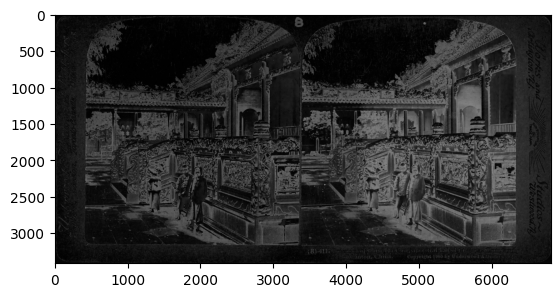

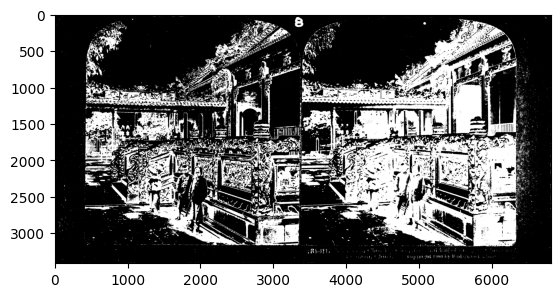

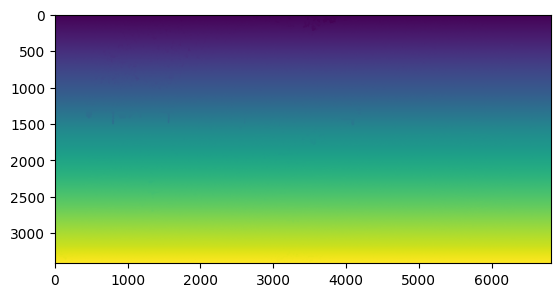

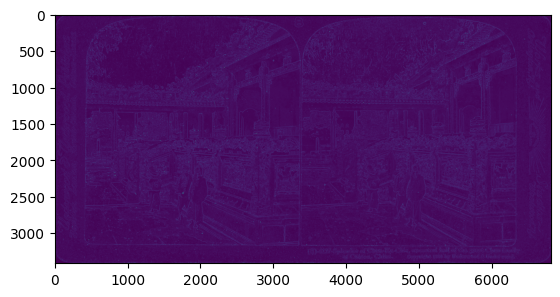

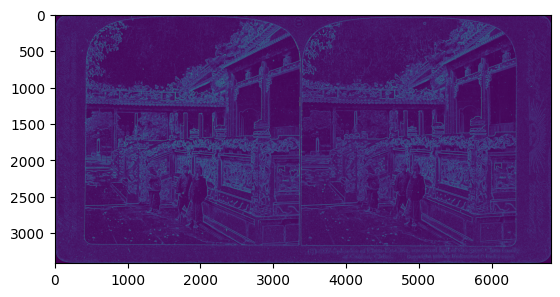

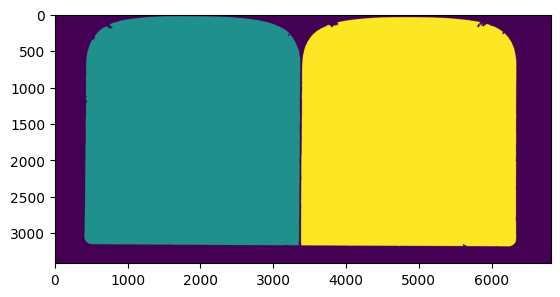

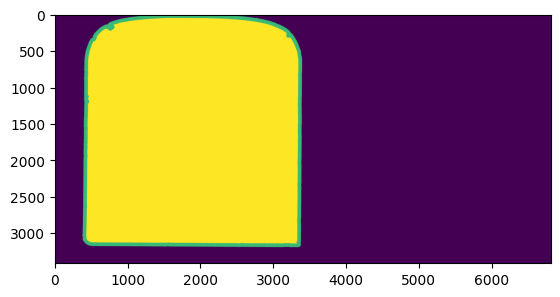

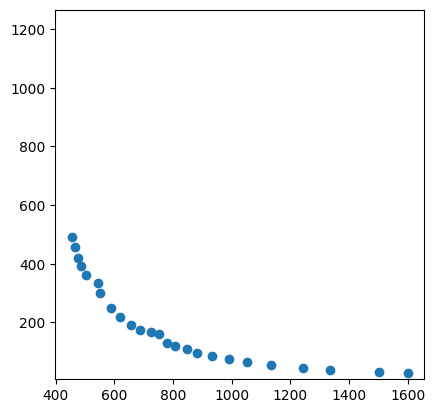

Completed processing of -SC5-8-1, Processing time: 40.16 seconds
Cropping failed


In [31]:
crop_file("../Data/StereoViews/-SC5-8-1.TIF")

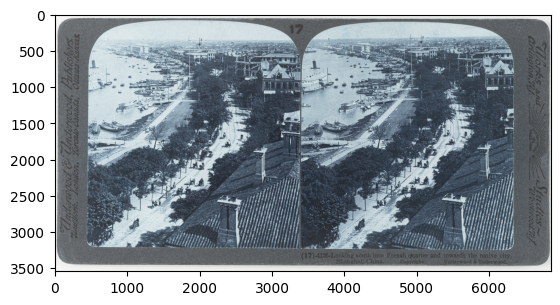

In [6]:
image = cv2.imread("../../Data/STEREO_VIEWS/ORIGINAL/-SC5-17-1.TIF")
b, g, r = cv2.split(image)
left_contours, _ = cv2.findContours(r, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
contours_drawn = cv2.drawContours(r, left_contours, -1, (255,255,255), 50)
plt.imshow(image)
plt.show()

In [7]:
def threshold_red_green(img, threshold=50):
    """
    Thresholds an image based on the difference between the red and green channels.
    
    Parameters:
    image_path (str): Path to the input image.
    threshold (int): The minimum difference between the red and green channels to keep a pixel.

    Returns:
    np.ndarray: Binary thresholded image.
    """
    
    # Extract red and green channels
    red_channel = img[:, :, 0]
    green_channel = img[:, :, 1]
    blue_channel = img[:, :, 2]
    
    # Compute the difference between red and green
    diff = blue_channel.astype(np.int16) - red_channel.astype(np.int16)

    binary_mask = np.where(
    ((diff > threshold) | (blue_channel < 100)), 
    255, 
    0
    ).astype(np.uint8)

    #binary_mask = np.where(
    #binary_mask & diff > 100 , 
    #255, 
    #0
    #).astype(np.uint8)

    return binary_mask

In [8]:
def channel_mix(img):
    red_channel = img[:, :, 0]
    green_channel = img[:, :, 1]
    red_channel = 2 * red_channel  - 1 * green_channel
    red_channel = np.clip(red_channel, 0, 255).astype(np.uint8)
    img[:, :, 0] = red_channel
    return img


In [9]:

def modify_hsl(img, hue_shift=16, saturation_scale=1.11, lightness_scale=1.04):

    # Convert from BGR to HLS
    img_hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS).astype(np.float32)

    # Split channels
    h, l, s = cv2.split(img_hls)

    # Modify Hue (ensure it stays in range 0-179 in OpenCV's HLS)
    h = (h + hue_shift) % 180  

    # Modify Saturation (ensure it stays in range 0-255)
    s = np.clip(s * saturation_scale, 0, 255)

    # Modify Lightness (ensure it stays in range 0-255)
    l = np.clip(l * lightness_scale, 0, 255)

    # Merge channels back
    img_hls_modified = cv2.merge([h, l, s]).astype(np.uint8)

    # Convert back to BGR
    img_bgr_modified = cv2.cvtColor(img_hls_modified, cv2.COLOR_HLS2BGR)

    return img_bgr_modified

# Example usage:
# modified_img = modify_hsl("image.jpg", hue_shift=10, saturation_scale=1.2, lightness_scale=0.9)
# cv2.imwrite("modified_image.jpg", modified_img)

In [10]:
def add_contrast(img, contrast=128):
    F = (259 * (contrast + 255)) / (255 * (259 - contrast))
    img = np.clip(F * (img - 128) + 128, 0, 255).astype(np.uint8)
    
    return img

In [11]:
def adjust_vibrance(img, vibrance=0):
    """
    Adjusts the vibrance of an image by selectively increasing the saturation of less saturated colors.
    
    Parameters:
    - image_path (str): Path to the input image.
    - vibrance (float): Vibrance adjustment factor (>0 to increase, <0 to decrease).
    
    Returns:
    - np.ndarray: The vibrance-adjusted image.
    """
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    
    H, S, V = cv2.split(hsv)

    # Compute the vibrance effect
    S_mean = np.mean(S)  # Find mean saturation level
    mask = S < S_mean  # Identify less saturated pixels
    S[mask] += vibrance * (S_mean - S[mask])  # Boost less saturated areas

    S = np.clip(S, 0, 255)  # Keep values in range

    hsv = cv2.merge([H, S, V])
    img_vibrant = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    return img_vibrant

In [12]:
def denoise_binary_image(img, kernel=4):
    kernel = np.ones((kernel,kernel), np.uint8)  # Small 3x3 kernel
    img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)  # Remove noise
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel) # Fill holes
    return img

In [13]:
def fill_white_until_black(img):
    h, w = img.shape

    # Process columns: Top-down and Bottom-up
    for x in range(w):  # Iterate over each column
        col = img[:, x]  # Extract column
        black_idx = np.where(col == 0)[0]  # Find indices of black pixels

        if black_idx.size > 0:
            # Top-down fill
            img[:black_idx[0], x] = 0  # Fill all pixels above the first black

            # Bottom-up fill
            img[black_idx[-1] + 1:, x] = 0  # Fill all pixels below the last black

    return img

In [14]:
from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

def get_right_boundary(image):
    
    X = []
    Y = []

    h, w = image.shape

    # Define window size
    window_height = h // 20
    window_width = 5

    

    # Iterate from right to left
    for y in range(6, 16):
        full_window = image[y*window_height:(y+1)*window_height, 6300:6500]
        percentage_of_black = np.count_nonzero(full_window == 0) / (window_height * 200)
        threshold = 300 if percentage_of_black < 0.7 else 150
        for x in range(6500, 6300, -1):  # Moves leftward
            # Extract the window region

            window = image[y*window_height:(y+1)*window_height, x:x + window_width]
            
            # Count white pixels (assuming 255 represents white)
            white_pixel_count = np.count_nonzero(window == 255)
            if(white_pixel_count > threshold):
                X.append(x)
                Y.append([int(y*window_height + window_height/2)])
                break

    reg = LinearRegression().fit(Y, X)
    return (reg.coef_, reg.intercept_)


def get_left_boundary(image):
    
    X = []
    Y = []

    h, w = image.shape

    # Define window size
    window_height = h // 20
    window_width = 5
    print(window_height)

    # Iterate from right to left
    for y in range(6, 16):
        full_window = image[y*window_height:(y+1)*window_height, 400:700]
        percentage_of_black = np.count_nonzero(full_window == 0) / (window_height * 200)
        threshold = 300 if percentage_of_black < 0.7 else 150
        for x in range(400, 700, 1):  # Moves leftward
            # Extract the window region

            window = image[y*window_height:(y+1)*window_height, x:x + window_width]
            
            # Count white pixels (assuming 255 represents white)
            white_pixel_count = np.count_nonzero(window == 255)
            print(white_pixel_count)
            if(white_pixel_count > threshold):
                X.append(x)
                Y.append([int(y*window_height + window_height/2)])
                break

    print(X)
    reg = LinearRegression().fit(Y, X)
    return (reg.coef_, reg.intercept_)

In [15]:
def get_middle_row(image):
    h, w = image.shape
    middle = (int(h/2), int(w/2))
    window = image[:,middle[1]-150:middle[1] + 150]
    # Count the number of zeros in each column
    zero_counts = np.sum(window == 0, axis=0)

    # Find the column index with the most zeros
    max_zero_column = np.argmax(zero_counts)
    return middle[1] - 150 + max_zero_column

In [16]:
def get_right_panel(a, b, middle_row, img):
    h, w = img.shape
    y_indices = np.arange(h)
    f_y = (a * y_indices + b).astype(int)  # Ensure integer indices
    # Apply the condition: x > f(y) → set to black (0)
    x_indices = np.arange(w)  # Column indices
    mask = x_indices[None, :] > f_y[:, None]  # Broadcasting to compare each (y, x)
    mask_z = x_indices[None, :] < middle_row 

    # Fill pixels where mask is True
    img[mask | mask_z] = 0
    return img

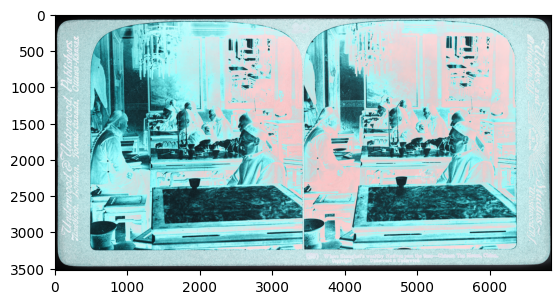

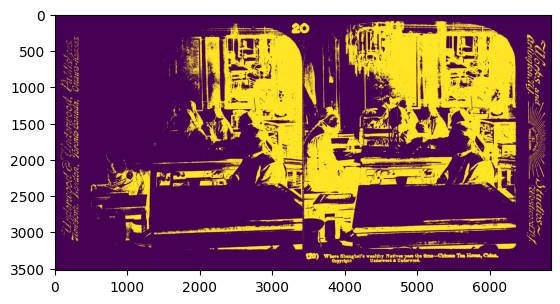

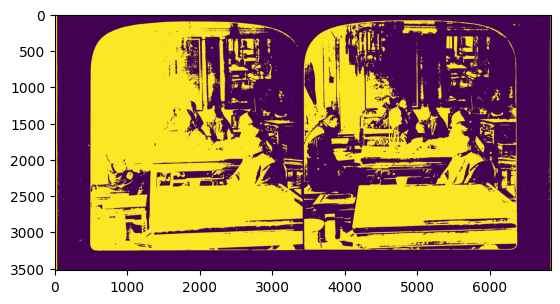

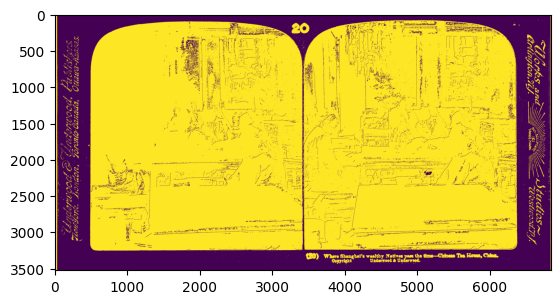

In [39]:
img = cv2.imread("../../Data/STEREO_VIEWS/ORIGINAL/-SC5-20-1.TIF")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_old = img.copy()
img = modify_hsl(img)
img = channel_mix(img)
img = cv2.convertScaleAbs(img, alpha=1.4, beta=-105)
img = cv2.bitwise_not(img)
img = adjust_vibrance(img,0.2)

thresh = threshold_red_green(img)

plt.imshow(img)
plt.show()

img_old = cv2.bitwise_not(img_old[:, :,1])
_, binary_image = cv2.threshold(img_old, 180, 255, cv2.THRESH_BINARY)

img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
#cv2.imwrite("test_3.tiff", img)


final = denoise_binary_image(thresh)
final = fill_white_until_black(final)
plt.imshow(binary_image)
plt.show()
plt.imshow(final)
plt.show()
plt.imshow(final + binary_image)

#cv2.imwrite("test_3.tiff", final)


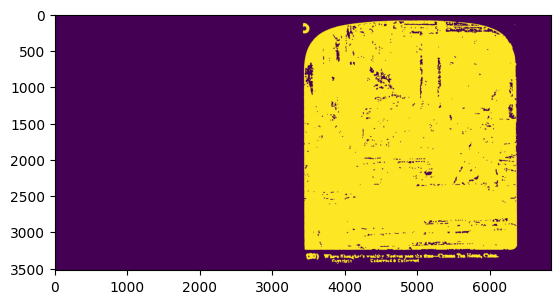

In [40]:
a, b = get_right_boundary(final)
c = get_middle_row(final)
right_panel = get_right_panel(a, b, c, final + binary_image)
right_panel = denoise_binary_image(right_panel, kernel=8)
plt.imshow(right_panel)